# Read data and randoms clustering catalogs

**Aim:** Read data and randoms clustering catalogs with the expand and shuffling option for the randoms. 

**Important:** This code can be run with MPI without any modification (srun -n X python ... ).

In [1]:
%load_ext autoreload
%autoreload 2

## IMPORTANT: for now it works with cosmodesi environment and for internal uses only -> need to update this for public release.

In [2]:
import os
import sys
from pathlib import Path
import numpy as np

import logging
from mpytools import Catalog, setup_logging

sys.path.insert(0, '../')
from clustering_statistics.tools import read_clustering_catalog, get_catalog_fn, propose_fiducial

from mpi4py import MPI
mpicomm = MPI.COMM_WORLD

# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

setup_logging(level=(logging.INFO if mpicomm.rank == 0 else logging.ERROR))

Let's have a look to the GLAM Mocks ! 

In [3]:
# version = 'glam-uchuu-v1-altmtl', 'holi-v1-altmtl', ...
# region = NGC, SGC, ALL (NGC+SGC), ... 
attrs = {'version': 'glam-uchuu-v1-altmtl', 'tracer': 'QSO', 'region': 'ALL', 'imock': 100}

# Different analysis are using different fiducial choices:
fiducial = propose_fiducial('catalog', tracer=attrs['tracer'], analysis='full_shape')
attrs.update(fiducial) 
print('Fiducial choice for catalog (Full Shape):', fiducial)
fiducial_png = propose_fiducial('catalog', tracer=attrs['tracer'], analysis='local_png')
print('Fiducial choice for catalog (Local PNG):', fiducial_png)

## For speed reason reduce the number of randoms for this demo:
attrs['nran'] = 1

print('')
print('data are located: ', get_catalog_fn(kind='data', **attrs))
print('randoms are located: ', get_catalog_fn(kind='randoms', **attrs))

Fiducial choice for catalog (Full Shape): {'weight': 'default-FKP', 'nran': 4, 'zranges': [(0.8, 2.1)], 'FKP_P0': 6000.0}
Fiducial choice for catalog (Local PNG): {'weight': 'default-fkp-oqe', 'nran': 4, 'zranges': [(0.8, 3.5), (0.8, 1.1), (0.8, 1.6)], 'FKP_P0': 30000.0}

data are located:  (PosixPath('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_NGC_clustering.dat.h5'), PosixPath('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_SGC_clustering.dat.h5'))
randoms are located:  [(PosixPath('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_NGC_0_clustering.ran.h5'), PosixPath('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_SGC_0_clustering.ran.h5'))]


In [4]:
help(get_catalog_fn)

Help on function get_catalog_fn in module clustering_statistics.tools:

get_catalog_fn(version=None, cat_dir=None, kind='data', tracer='LRG', region='NGC', weight='default-FKP', nran=10, imock=0, ext='h5', **kwargs)
    Return catalog file name(s) for given parameters.

    Parameters
    ----------
    version : str
        Catalog version. Options are 'data-dr1-v1.5', 'data-dr2-v2', 'holi-v1-complete', 'holi-v1-altmtl'.
    cat_dir : str, Path, optional
        Directory containing the catalogs. If None, pre-registered paths will be used based on version.
    kind : str
        Catalog kind. Options are 'data', 'randoms', 'full_data', 'full_randoms'.
    tracer : str
        Tracer name. Options are 'BGS', 'LRG', 'LGE', 'ELG', 'LRG+ELG', 'QSO'.
    region : str
        Region name. Options are 'NGC', 'SGC', 'N', 'S', 'ALL', 'NGCnoN', 'SGCnoDES'.
    weight : str
        Weight type. Options are 'default-FKP', 'defaut-bitwise-FKP', etc.
    nran : int, list
        Number of random ca

In [5]:
print('Reading data catalog...')
print(Catalog.read(get_catalog_fn(kind='data', **attrs), group='LSS', locking=False, mpicomm=mpicomm))

print('')
print('Reading randoms catalog...')
fns = get_catalog_fn(kind='randoms', **attrs)  # a list (each of nran randoms) of tuple of file names ('NGC', 'SGC')
fns = [ff for fn in fns for ff in fn]  # flatten
print(Catalog.read(fns, group='LSS', locking=False, mpicomm=mpicomm))

print('')
print('Randoms do not contain all the expected columns. This is for memory reason, we do not write and save RA, DEC, Z,... that are the same for all the mock realisations.')
print('We are providing a way to read the catalogs with read_clustering_catalog function.')
print('')

Reading data catalog...
[000000.60] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_NGC_clustering.dat.h5.
[000000.64] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_SGC_clustering.dat.h5.
Catalog(csize=2022651, size=2022651, columns=['DEC', 'FRAC_TLOBS_TILES', 'NTILE', 'NX', 'PHOTSYS', 'RA', 'TARGETID', 'TILEID', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_FKP', 'WEIGHT_IMLIN', 'WEIGHT_SYS', 'WEIGHT_ZFAIL', 'Z'])

Reading randoms catalog...
[000000.72] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_NGC_0_clustering.ran.h5.
[000000.73] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl10

In [6]:
expand = {'parent_randoms_fn': get_catalog_fn(kind='parent_randoms', version='data-dr2-v2', tracer=attrs['tracer'], nran=attrs['nran'])}
randoms = read_clustering_catalog(kind='randoms', expand=expand, keep_columns=True, mpicomm=mpicomm, **attrs) 
print(randoms)

[000000.89] [0/1] 05-28 16:18  tools                     INFO     Expanding randoms
[000000.89] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5.
[000000.90] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5.
[000000.91] [0/1] 05-28 16:18  tools                     WARNING  WEIGHT not in catalog: /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5
[000001.06] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_NGC_clustering.dat.h5.
[000001.07] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_SGC_clustering.dat.h5.
[000001.07] [0

In [7]:
# Let's have a look to the weight columns called INDWEIGHT (for individual weights):
data = read_clustering_catalog(kind='data', keep_columns=True, mpicomm=mpicomm, **attrs)
print(attrs['weight'], data) 

# First compute the mean completeness weight as a function of 'NTILE'
from clustering_statistics.tools import  _compute_binned_weight
weight_ntl = _compute_binned_weight(data['NTILE'], data['WEIGHT_COMP'])[data['NTILE']] 
# Compute the total weights:
weight = data['WEIGHT_COMP'] * data['WEIGHT_SYS'] * data['WEIGHT_ZFAIL'] / weight_ntl

# For mocks, the result is not exactly the same because of the float compression in the mock files.
print('')
print('Without FKP weights:')
print(data['WEIGHT'])
print(weight)

print('')
print('With FKP weights:')
print(data['INDWEIGHT'])
print(weight * data['WEIGHT_FKP'])

[000029.09] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_NGC_clustering.dat.h5.
[000029.10] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_SGC_clustering.dat.h5.
[000029.10] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_NGC_clustering.dat.h5.
[000029.10] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_SGC_clustering.dat.h5.
[000029.64] [0/1] 05-28 16:18  tools                     INFO     Multiplying individual weights by FKP weight computed with FKP_P0 = 6000.0
default-FKP Catalog(csize=2022651, size=2022651, columns=['DEC', 'FRAC_TLOBS_TI

## On-the-fly reshuffling

In [8]:
# For the mocks, you can also reshuffle randoms on the fly (this is slow without MPI), especially to test RIC.

# First, pass expand if randoms do not have RA, DEC, and NTILE columns:
# You need also to extract FRAC_TLOBS_TILES from the data that is part of the completeness which is applied only to the randoms.
# But you don't need to extract Z, WEIGHT_SYS, ... because we are reshuffling the randoms !
# Note: you do not need to provide 'from_data' it is done automatically if reshuffling is performed, but I put it here for clarity.
expand = {'parent_randoms_fn': get_catalog_fn(kind='parent_randoms', version='data-dr2-v2', tracer=attrs['tracer'], nran=attrs['nran']), 
          'from_data': ['FRAC_TLOBS_TILES']}   

# Then provide directory to merged data catalogs (we will draw the redshift from the concatenates mock data catalogs, removing the effect of RIC)
# merged_dir = Path('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/') /  attrs['version'] / 'merged'
# merged_data_fn = get_catalog_fn(kind='data', cat_dir=merged_dir, **(attrs | dict(region='ALL')))

# for this tiny example use instead the data catalog of the same mocks (THIS WILL NOT REMOVE THE RIC effect !!)
merged_data_fn = get_catalog_fn(kind='data', **(attrs | dict(region='ALL')))
print(merged_data_fn)

reshuffle = {'merged_data_fn': merged_data_fn}
randoms_reshuffled = read_clustering_catalog(kind='randoms', expand=expand, reshuffle=reshuffle, mpicomm=mpicomm, **attrs) 
print(randoms_reshuffled)

(PosixPath('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_NGC_clustering.dat.h5'), PosixPath('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl100/loa-v1/mock100/LSScats/QSO_SGC_clustering.dat.h5'))
[000030.68] [0/1] 05-28 16:18  tools                     INFO     Expanding randoms
[000030.68] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5.
[000030.69] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5.
[000030.70] [0/1] 05-28 16:18  tools                     WARNING  WEIGHT not in catalog: /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5
[000030.86] [0/1] 05-28 16:18  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/

/global/u2/e/edmondc/desi-clustering/nb/../clustering_statistics/tools.py:2451: RuntimeWarning: invalid value encountered in divide
  nz = np.where(nz_now > 0, nz / nz_now, 0.)


[000054.77] [0/1] 05-28 16:19  Footprint                 INFO     Load DR9 footprint with nside=256, mask_lmc=False, clear_south=True, mask_around_des=False and cut_desi=False
[000079.49] [0/1] 05-28 16:19  tools                     INFO     alpha after renormalization & reweighting: [1.00032868 0.99993591 0.99971796]
[000079.52] [0/1] 05-28 16:19  tools                     INFO     Reshuffling randoms completed in 28.3 s
[000081.04] [0/1] 05-28 16:19  tools                     INFO     Multiplying individual weights by FKP weight computed with FKP_P0 = 6000.0
Catalog(csize=27929969, size=27929969, columns=['NX', 'TARGETID', 'WEIGHT', 'RA', 'DEC', 'NTILE', 'FRAC_TLOBS_TILES', 'Z', 'WEIGHT_SYS', 'WEIGHT_FKP', 'INDWEIGHT', 'POSITION'])


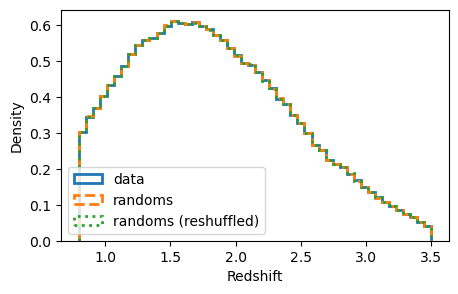

In [9]:
import matplotlib.pyplot as plt
hist_kws = dict(bins=50, histtype='step', density=True, lw=2)
plt.figure(figsize=(5, 3))
plt.hist(data['Z'], weights=data['INDWEIGHT'], label='data', ls='-', **hist_kws)
plt.hist(randoms['Z'], weights=randoms['INDWEIGHT'], label='randoms', ls='--', **hist_kws)
plt.hist(randoms_reshuffled['Z'], weights=randoms_reshuffled['INDWEIGHT'], label='randoms (reshuffled)', ls=':', **hist_kws)
plt.xlabel('Redshift')
plt.ylabel('Density')
plt.legend()
plt.show()

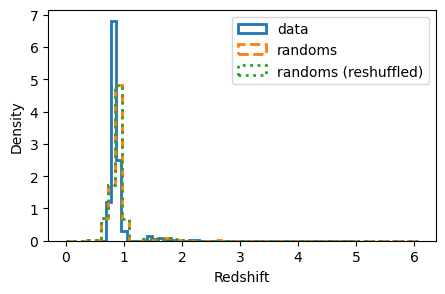

In [10]:
import matplotlib.pyplot as plt
hist_kws = dict(bins=50, histtype='step', density=True, lw=2)
plt.figure(figsize=(5, 3))
plt.hist(data['INDWEIGHT'], label='data', ls='-', **hist_kws)
plt.hist(randoms['INDWEIGHT'], label='randoms', ls='--', **hist_kws)
plt.hist(randoms_reshuffled['INDWEIGHT'], label='randoms (reshuffled)', ls=':', **hist_kws)
plt.xlabel('Redshift')
plt.ylabel('Density')
plt.legend()
plt.show()

## On-the-fly complete mocks
It is possible to create completeness-weighted complete (i.e. "without fiber assignment") mocks.

In [ ]:
# Define catalog options
tracer = 'LRG'
version = 'glam-uchuu-v1-altmtl'
catalog_options = dict(version=version, tracer=tracer, zrange=(0.8, 1.1), region='NGC', weight='default', imock=128, nran=2)

# Pass complete = {} to create a complete data catalog on-the-fly
# And reshuffle to store the new (complete) data catalog to resample redshifts from in cache
complete, reshuffle = {}, {}
data = read_clustering_catalog(kind='data', complete=complete, reshuffle=reshuffle, **catalog_options)
# Can be combined with expand
expand = {'parent_randoms_fn': get_catalog_fn(kind='parent_randoms', version='data-dr2-v2', tracer=tracer, nran=catalog_options['nran'])}
randoms = read_clustering_catalog(kind='randoms', complete=complete, reshuffle=reshuffle, expand=expand, **catalog_options)

[000093.08] [0/1] 05-28 16:19  tools                     INFO     On-the-fly complete data.
[000093.08] [0/1] 05-28 16:19  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl128/loa-v1/mock128/LSScats/LRG_full_HPmapcut.dat.h5.
[000093.10] [0/1] 05-28 16:19  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl128/loa-v1/mock128/LSScats/LRG_full_HPmapcut.dat.h5.
[000093.11] [0/1] 05-28 16:19  tools                     WARNING  WEIGHT not in catalog: /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/altmtl128/loa-v1/mock128/LSScats/LRG_full_HPmapcut.dat.h5
[000093.11] [0/1] 05-28 16:19  FileStack                 INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/GLAM-Uchuu_v1/forFA128.fits.
